This is the model that ran fully and is used in the SDP ALL DETECTOR SOFTWARE
APPLICATION

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install --upgrade tensorflow==2.20.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.6 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is in

In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set parameters
data_dir = "/content/drive/MyDrive/Dataset"
MODEL_VARIANT = "B3"
batch_size = 32

In [ ]:
# Load dataset with split
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # training 80%, keeping the 20% for validation
    subset="training",
    seed=123,
    image_size=(300,300),
    color_mode="rgb",
    batch_size=batch_size,
    label_mode="int"  # for multi-class classification
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # using the 20% for val
    subset="validation",
    seed=123,
    image_size=(300,300),
    color_mode="rgb",
    batch_size=batch_size,
    label_mode="int"
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)

# Improve performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 22036 files belonging to 4 classes.
Using 17629 files for training.
Found 22036 files belonging to 4 classes.
Using 4407 files for validation.
Class names: ['Early Pre-B-ALL', 'Not ALL', 'Pre-B-ALL', 'Pro B-ALL']


In [ ]:
for images, labels in train_ds.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)
    print("Sample labels:", labels[:10].numpy())  # first 10 labels


Images batch shape: (32, 300, 300, 3)
Labels batch shape: (32,)
Sample labels: [3 3 0 0 1 0 2 2 0 3]


In [ ]:
for images, labels in train_ds.take(1):
    print("Label dtype:", labels.dtype)
    print("Unique labels:", tf.unique(labels).y.numpy() if len(labels.shape)==1 else "One-hot encoded")


Label dtype: <dtype: 'int32'>
Unique labels: [2 3 1 0]


Pre-Processing and Data augmentation is already applied

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import mixed_precision
from tensorflow.keras.regularizers import l2

# Enable mixed precision globally
mixed_precision.set_global_policy("mixed_float16")

num_classes = 4

# Load EfficientNetB3 backbone
base_model = EfficientNetB3(
    weights="imagenet",        # Pretrained on ImageNet
    include_top=False,         # Remove default classifier
    input_shape=(300,300, 3)
)
base_model.trainable = False   # Freeze backbone initially

# Build model with Functional API
inputs = keras.Input(shape=(300, 300, 3))
x = base_model(inputs, training=False)   # pass inputs explicitly
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,           # stop if val_loss doesn’t improve for 5 epochs
    restore_best_weights=True
)

# Reduce learning rate when plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,           # reduce LR by 20%
    patience=3,           # wait 3 epochs before reducing LR
    min_lr=1e-6
)


In [ ]:
# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs= 6,callbacks=[early_stopping, reduce_lr],
    verbose=1)

Epoch 1/6
551/551 ━━━━━━━━━━━━━━━━━━━━ 876s 1s/step - accuracy: 0.5833 - loss: 1.5720 - val_accuracy: 0.9170 - val_loss: 0.6806 - learning_rate: 1.0000e-04
Epoch 2/6
551/551 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.8301 - loss: 0.8928 - val_accuracy: 0.9381 - val_loss: 0.5993 - learning_rate: 1.0000e-04
Epoch 3/6
551/551 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.8617 - loss: 0.7767 - val_accuracy: 0.9508 - val_loss: 0.5477 - learning_rate: 1.0000e-04
Epoch 4/6
551/551 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.8787 - loss: 0.7287 - val_accuracy: 0.9598 - val_loss: 0.5060 - learning_rate: 1.0000e-04
Epoch 5/6
551/551 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.8912 - loss: 0.6733 - val_accuracy: 0.9610 - val_loss: 0.4848 - learning_rate: 1.0000e-04
Epoch 6/6
551/551 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.8912 - loss: 0.6523 - val_accuracy: 0.9644 - val_loss: 0.4569 - learning_rate: 1.0000e-04


In [ ]:
# Save the entire model
import os
os.makedirs('/content/drive/MyDrive', exist_ok=True)
model.save("efficientnet_2_all_20.keras")

In [ ]:
import os
#os.makedirs('/content/drive/MyDrive/customcnn_2_all', exist_ok=True)
# for fast api
#save_path = '/content/drive/MyDrive/customcnn_2_all'
model.save('efficientnet_2_all_20.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step


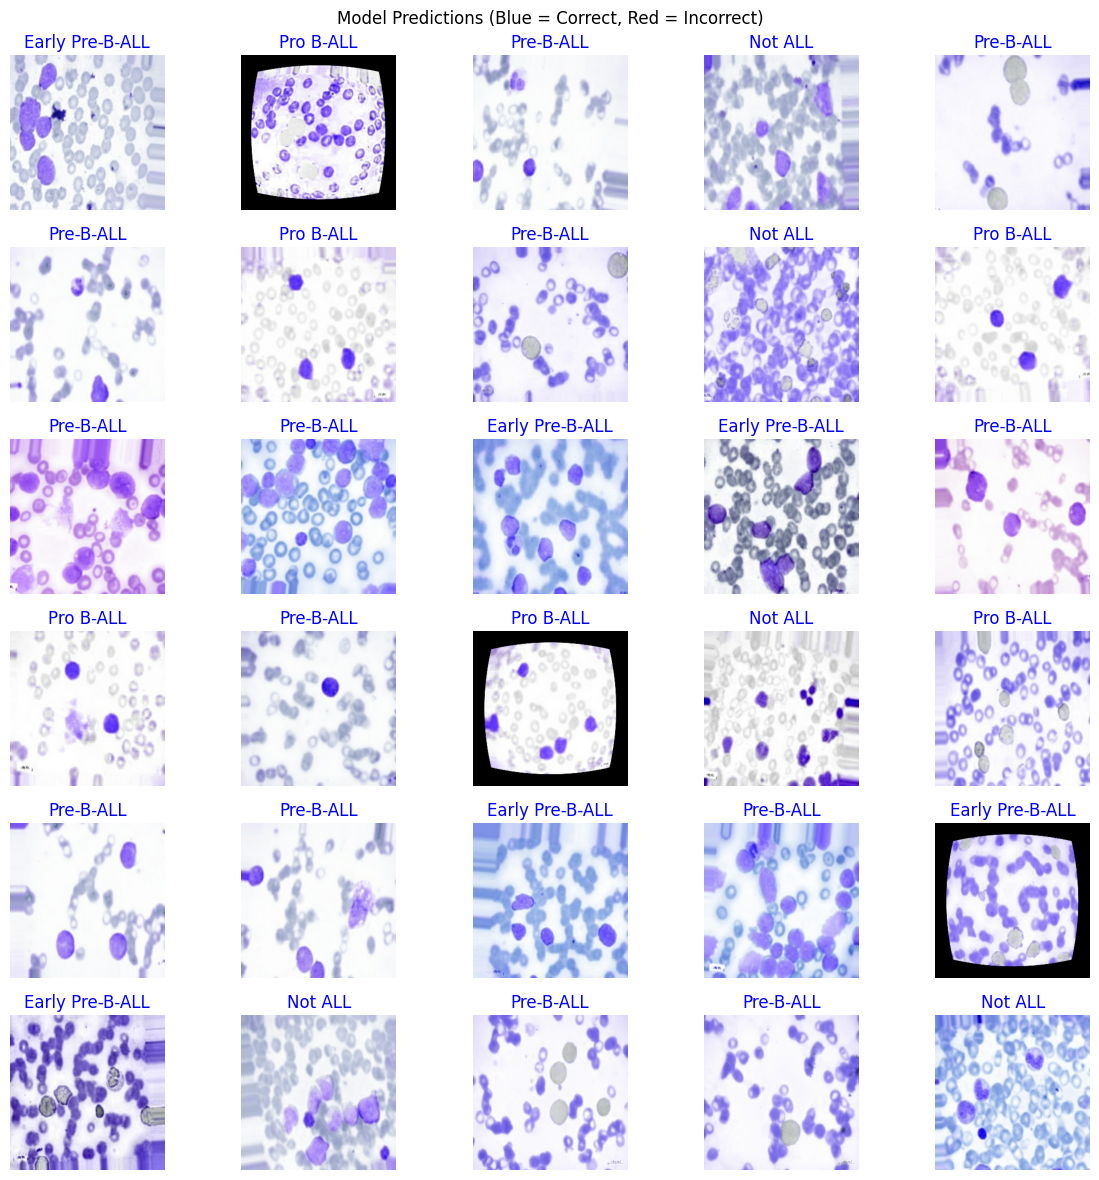

In [ ]:
# Prediction visualization
image_batch, label_batch = next(iter(train_ds.take(1)))
predicted_batch = model.predict(image_batch)
predicted_ids = np.argmax(predicted_batch, axis=-1)
predicted_class_names = [class_names[i] for i in predicted_ids]

# Plot predictions
plt.figure(figsize=(12, 12))
for n in range(min(30, len(image_batch))):
    plt.subplot(6, 5, n + 1)
    plt.imshow(image_batch[n].numpy().astype("uint8"))
    color = "blue" if predicted_ids[n] == label_batch[n].numpy() else "red"
    plt.title(predicted_class_names[n], color=color)
    plt.axis('off')
plt.suptitle("Model Predictions (Blue = Correct, Red = Incorrect)")
plt.tight_layout()
plt.show()


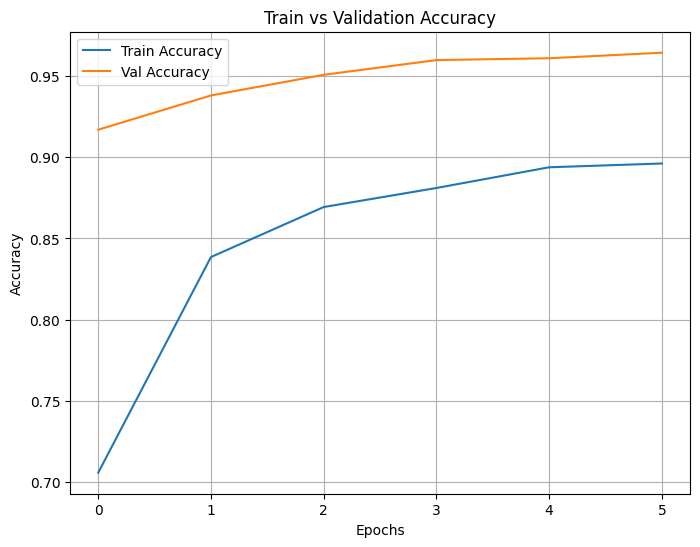

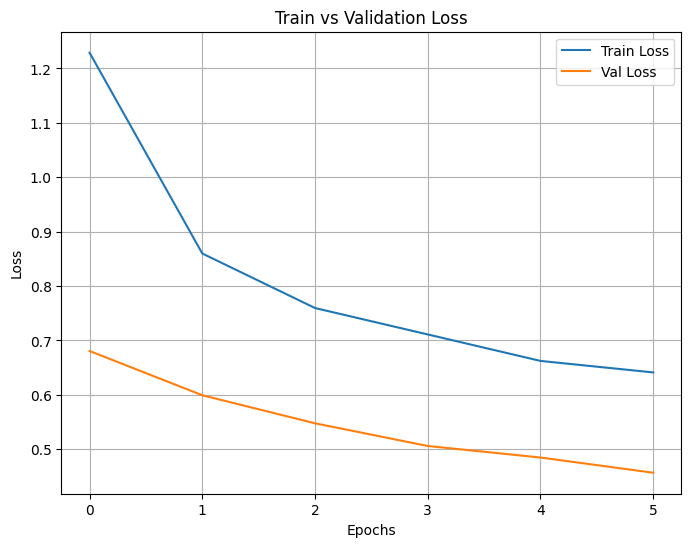

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("train_vs_val_accuracy.png")
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig("Train vs Validation Loss.png")
plt.show()


/tmp/ipython-input-4155074125.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


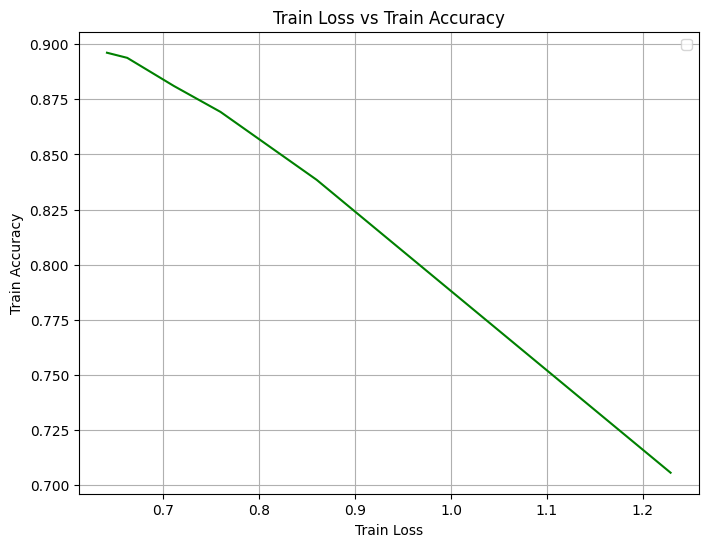

/tmp/ipython-input-4155074125.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


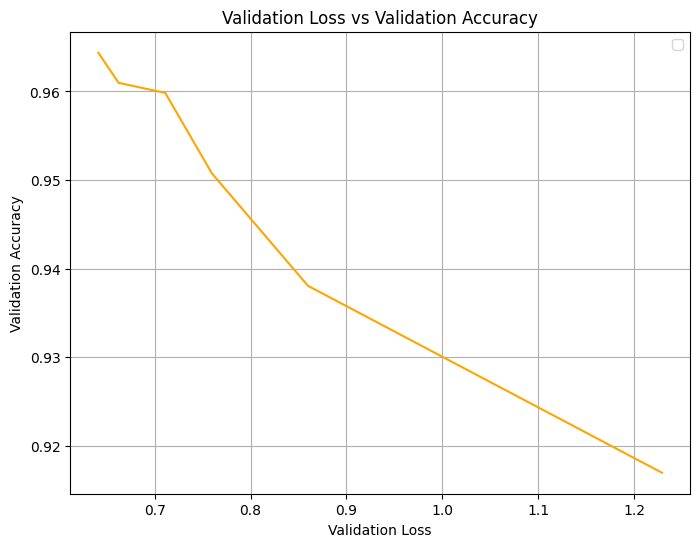

In [ ]:
# Plot: Train loss vs Train accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], history.history['accuracy'], color='green')
plt.xlabel('Train Loss')
plt.ylabel('Train Accuracy')
plt.title('Train Loss vs Train Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("train_loss_vs_train_accuracy.png")
plt.show()

# Plot: val loss vs Val accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], history.history['val_accuracy'], color='orange')
plt.xlabel('Validation Loss')
plt.ylabel('Validation Accuracy')
plt.title('Validation Loss vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig("val_acc_vs_val_loss.png")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━

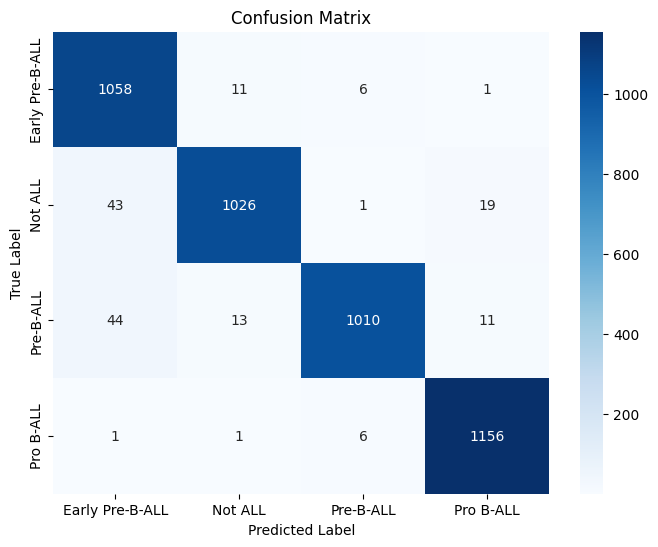

Classification Report:
               precision    recall  f1-score   support

  all_benign       0.92      0.98      0.95      1076
   all_early       0.98      0.94      0.96      1089
     all_pre       0.99      0.94      0.96      1078
     all_pro       0.97      0.99      0.98      1164

    accuracy                           0.96      4407
   macro avg       0.97      0.96      0.96      4407
weighted avg       0.97      0.96      0.96      4407

Classification Report:

                 precision    recall  f1-score   support

Early Pre-B-ALL     0.9232    0.9833    0.9523      1076
        Not ALL     0.9762    0.9421    0.9589      1089
      Pre-B-ALL     0.9873    0.9369    0.9614      1078
      Pro B-ALL     0.9739    0.9931    0.9834      1164

       accuracy                         0.9644      4407
      macro avg     0.9652    0.9639    0.9640      4407
   weighted avg     0.9654    0.9644    0.9644      4407



<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# class in tf_flowers
class_name = ['all_benign', 'all_early', 'all_pre', 'all_pro']

# Get true labels and predictions
y_true = []
y_pred = []


for images, labels in val_ds:
    predictions = model.predict(images)  # Get predicted probabilities
    y_true.extend(labels.numpy())  # Store true labels
    y_pred.extend(np.argmax(predictions,axis=1))  # Convert probs to class labels using argmax
# grabs the index of the class with highest probability, for each image.

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred) #compares predictions vs. true labels.

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names = class_name))
#classification_report() — gives precision, recall, and F1-score per class

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
plt.savefig("confusion_matrix.png")
print(report)


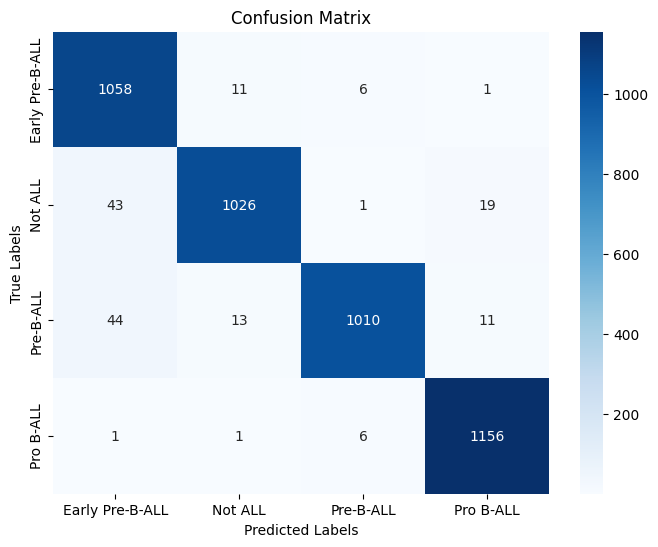

Classification Report:

                 precision    recall  f1-score   support

Early Pre-B-ALL     0.9232    0.9833    0.9523      1076
        Not ALL     0.9762    0.9421    0.9589      1089
      Pre-B-ALL     0.9873    0.9369    0.9614      1078
      Pro B-ALL     0.9739    0.9931    0.9834      1164

       accuracy                         0.9644      4407
      macro avg     0.9652    0.9639    0.9640      4407
   weighted avg     0.9654    0.9644    0.9644      4407



<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions from the validation set
y_true = []
y_pred = []

for images, labels in val_ds.unbatch():
    y_true.append(int(labels.numpy()))
    preds = model.predict(tf.expand_dims(images, axis=0), verbose=0)
    y_pred.append(np.argmax(preds))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
plt.savefig("confusion_matrix.png")
print(report)


In [ ]:
# Print precision, recall, f1-score, support
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)

# Optional: Save report to .txt file
with open("classification_report.txt", "w") as f:
    f.write(report)


Classification Report:

                 precision    recall  f1-score   support

Early Pre-B-ALL     0.9232    0.9833    0.9523      1076
        Not ALL     0.9762    0.9421    0.9589      1089
      Pre-B-ALL     0.9873    0.9369    0.9614      1078
      Pro B-ALL     0.9739    0.9931    0.9834      1164

       accuracy                         0.9644      4407
      macro avg     0.9652    0.9639    0.9640      4407
   weighted avg     0.9654    0.9644    0.9644      4407



In [ ]:
print(model.input_shape)


(None, 300, 300, 3)


In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 300, 300, 3)


In [ ]:
loaded = tf.keras.models.load_model("efficientnet_2_all_20.keras")
print(loaded.input_shape)

(None, 300, 300, 3)


In [ ]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,969,089 (45.66 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

 Optimizer params: 790,030 (3.01 MB)

In [ ]:
# Save the entire model
import os
os.makedirs('/content/drive/MyDrive', exist_ok=True)
model.save("efficientnet_2_all_20.keras")